In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [2]:
import seaborn as sns
import matplotlib.pylab as plt
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

df_tr = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/train.csv', index_col = 'id')
df_tst = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/test.csv', index_col = 'id')
subs = pd.read_csv('/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv')
df_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 691369 entries, 0 to 691368
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      662440 non-null  float64
 1   daily_screen_time_hours  595515 non-null  float64
 2   social_media_hours       557374 non-null  float64
 3   gaming_hours             564548 non-null  float64
 4   work_study_hours         639851 non-null  float64
 5   sleep_hours              646889 non-null  float64
 6   notifications_per_day    623785 non-null  float64
 7   app_opens_per_day        610659 non-null  float64
 8   weekend_screen_time      579306 non-null  float64
 9   gender                   662335 non-null  object 
 10  stress_level             636221 non-null  object 
 11  academic_work_impact     647145 non-null  object 
 12  addicted_label           691369 non-null  int64  
dtypes: float64(9), int64(1), object(3)
memory usage: 73.8+ MB


## Feature Selection

In [3]:
num_tst = df_tst.select_dtypes(include = ['number'])
num_tst.agg(['mean','median', 'std', 'min', 'max']).T

,mean,median,std,min,max
age,26.608689,27.00,5.153359,18.00,35.00
daily_screen_time_hours,7.640771,7.77,2.725921,0.50,15.00
social_media_hours,2.471224,2.32,1.318143,0.00,7.85
gaming_hours,1.457668,1.33,0.934727,0.00,4.00
work_study_hours,2.365962,2.20,1.257023,0.00,6.00
sleep_hours,6.801704,6.80,1.236080,4.50,9.00
notifications_per_day,145.748066,150.00,66.014554,20.00,250.00
app_opens_per_day,102.656216,104.00,48.186200,15.00,180.00
weekend_screen_time,9.474575,9.58,2.858384,0.51,17.56


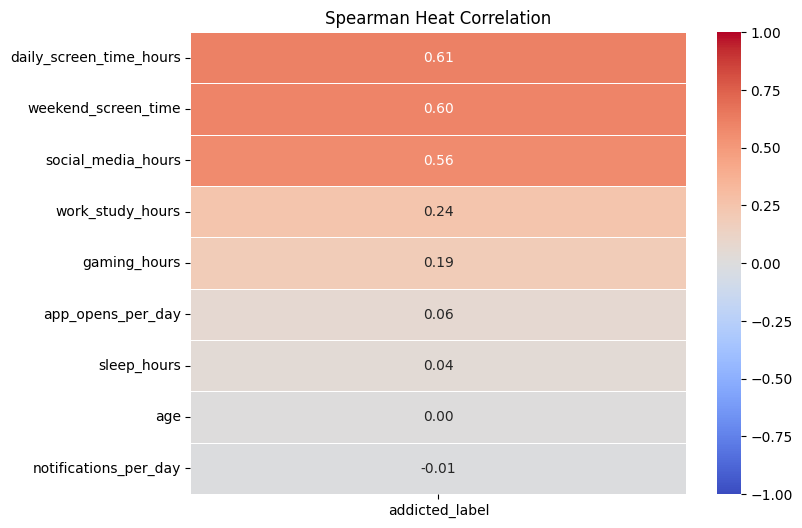

In [4]:
num = df_tr.select_dtypes(include = ['number'])
corr_mat = num.corr(method = 'spearman')
target_val = 'addicted_label'
ind_vars = corr_mat[[target_val]].drop(target_val)

one_d_corr = ind_vars.sort_values(by = target_val, ascending = False)

plt.figure(figsize = (8,6))
sns.heatmap(one_d_corr, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidth = 0.5, vmin = -1, vmax = 1)
plt.title('Spearman Heat Correlation')
plt.tight_layout
plt.show()

In [5]:
import statsmodels.api as sm

X = num.drop(columns = 'addicted_label')
y = num['addicted_label']

X = sm.add_constant(X)
model = sm.Logit(y, X, missing = 'drop').fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.309413
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         addicted_label   No. Observations:               306175
Model:                          Logit   Df Residuals:                   306165
Method:                           MLE   Df Model:                            9
Date:                Sat, 29 Aug 2026   Pseudo R-squ.:                  0.4877
Time:                        02:27:15   Log-Likelihood:                -94735.
converged:                       True   LL-Null:                   -1.8491e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -6.7693      0.055   -123.879      0.000      -6.876   

In [6]:
# t-test 
# The t-test is a statistical method used to determine whether the means of two data groups differ significantly.
from scipy import stats
group_0 = num[num['addicted_label'] == 0]
group_1 = num[num['addicted_label'] == 1]

def pval_check(column):
    t_stat, p_val = stats.ttest_ind(group_0[column], group_1[column], nan_policy = 'omit', equal_var = False)
    return print(f'P value for {column}', p_val)

pval_check("age")

P value for age 0.0011343322339723


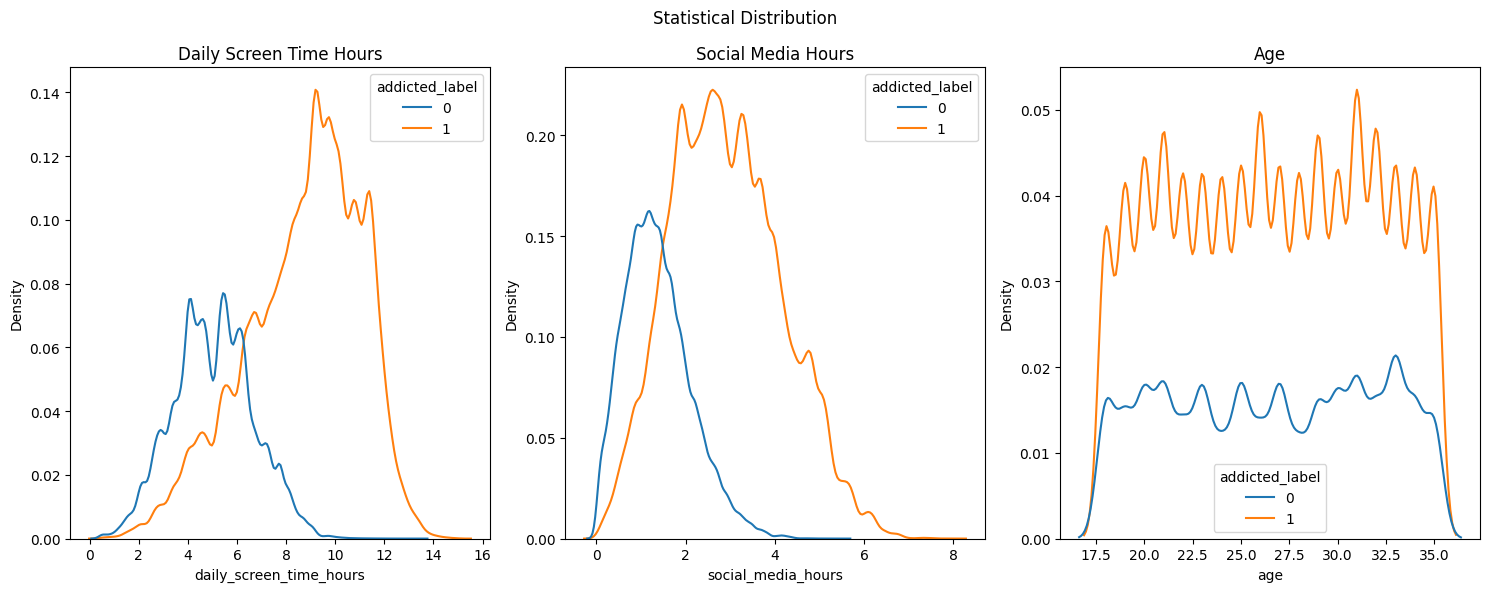

In [7]:
fig, ax = plt.subplots(1,3, figsize = (15,6))

sns.kdeplot(x = df_tr['daily_screen_time_hours'], hue = df_tr['addicted_label'], ax = ax[0])
sns.kdeplot(x = df_tr['social_media_hours'], hue = df_tr['addicted_label'], ax = ax[1])
sns.kdeplot(x = df_tr['age'], hue = df_tr['addicted_label'], ax = ax[2])
plt.suptitle("Statistical Distribution")
ax[0].set_title('Daily Screen Time Hours')
ax[1].set_title('Social Media Hours')
ax[2].set_title('Age')
fig.tight_layout()


In [8]:
num_tr = df_tr.select_dtypes(include = 'float64')
(num_tr.isnull().sum()/len(num_tr))*100

age                         4.184307
daily_screen_time_hours    13.864376
social_media_hours         19.381112
gaming_hours               18.343461
work_study_hours            7.451592
sleep_hours                 6.433612
notifications_per_day       9.775388
app_opens_per_day          11.673940
weekend_screen_time        16.208855
dtype: float64

In [9]:
(num_tst.isnull().sum()/len(num_tst))*100

age                         5.783964
daily_screen_time_hours    11.065737
social_media_hours         15.996180
gaming_hours               20.053864
work_study_hours            9.374557
sleep_hours                 7.578417
notifications_per_day      11.549365
app_opens_per_day           8.675271
weekend_screen_time        17.109908
dtype: float64

In [10]:
# fillna
def fill_nan(data, column = None, method = None):
    if column is None or method is None:
        print('Error: fill "column" and "method"')
        return data
        
    df_c = data.copy()
    
    if method == 'mean':
        df_c[column] = df_c[column].fillna(df_c[column].mean())
    elif method == 'median':
        df_c[column] = df_c[column].fillna(df_c[column].median())
    elif method == 'mode':
        mode_series =df_c[column].mode()
        if not mode_series.empty:
            df_c[column] = df_c[column].fillna(mode_series[0])
        else:
            print(f"{column} do not have mode")
    else:
        print(f"Error: The {method} is unknown. choose: mean, median, mode")

    return df_c


In [11]:
num_tr = df_tr.select_dtypes(include = ['number'])
num_tr.agg(['median','mean','std', 'min', 'max']).T

,median,mean,std,min,max
age,27.00,26.615408,5.153162,18.00,35.00
daily_screen_time_hours,7.77,7.640865,2.721446,0.50,15.00
social_media_hours,2.31,2.471038,1.316137,0.00,8.00
gaming_hours,1.33,1.459265,0.934552,0.00,4.00
work_study_hours,2.20,2.366971,1.258797,0.00,6.00
sleep_hours,6.80,6.804334,1.234512,4.50,9.00
notifications_per_day,150.00,145.894900,65.917556,20.00,250.00
app_opens_per_day,104.00,102.636781,48.093970,15.00,180.00
weekend_screen_time,9.58,9.479866,2.856006,0.51,17.56
addicted_label,1.00,0.709424,0.454028,0.00,1.00


In [12]:
col_median = ['age', 'social_media_hours', 'work_study_hours','sleep_hours','weekend_screen_time']
col_mean = ['daily_screen_time_hours', 'gaming_hours', 'notifications_per_day', 'app_opens_per_day']
col_mode = df_tr.select_dtypes(include = ['object', 'category']).columns
df_tr.isnull().sum()

age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [13]:
# fillna
df_tr_copy = df_tr.copy()
for col in col_median:
    df_tr_copy = fill_nan(df_tr_copy, col, 'median')

df_tr_copy.isnull().sum()

age                             0
daily_screen_time_hours     95854
social_media_hours              0
gaming_hours               126821
work_study_hours                0
sleep_hours                     0
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time             0
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [14]:
for col in col_mean:
    df_tr_copy = fill_nan(df_tr_copy, col, 'mean')

df_tr_copy.isnull().sum()

age                            0
daily_screen_time_hours        0
social_media_hours             0
gaming_hours                   0
work_study_hours               0
sleep_hours                    0
notifications_per_day          0
app_opens_per_day              0
weekend_screen_time            0
gender                     29034
stress_level               55148
academic_work_impact       44224
addicted_label                 0
dtype: int64

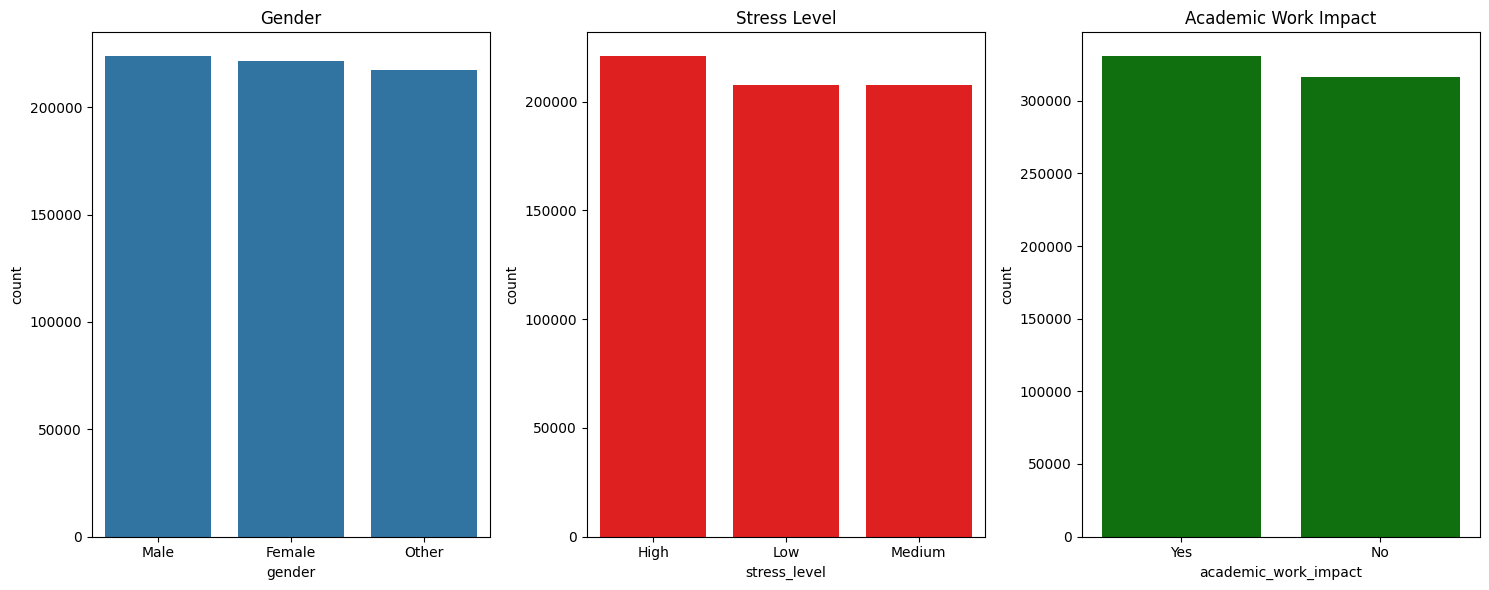

In [15]:
fig, ax = plt.subplots(1,3, figsize = (15,6))

sns.countplot(df_tr_copy, x = 'gender', order = df_tr_copy['gender'].value_counts().index, ax = ax[0])
sns.countplot(df_tr_copy, x = 'stress_level', order = df_tr_copy['stress_level'].value_counts().index, ax = ax[1], color = 'red')
sns.countplot(df_tr_copy, x = 'academic_work_impact', order = df_tr_copy['academic_work_impact'].value_counts().index, ax = ax[2], color = 'green')
ax[0].set_title('Gender')
ax[1].set_title('Stress Level')
ax[2].set_title('Academic Work Impact')
fig.tight_layout()
plt.show()

In [16]:
# object feature selection
from scipy.stats import chi2_contingency

# save the feature importance
imp_feat = []

for col in col_mode:
    contingency_table = pd.crosstab(df_tr_copy[col], df_tr_copy['addicted_label'])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    if p < 0.05:
        imp_feat.append(col)
        print(f"{col} is significant (p-value: {p:.5f})")
    else:
        print(f"{col} is not significant(p-value: {p:.5f})")

gender is significant (p-value: 0.00000)
stress_level is significant (p-value: 0.00002)
academic_work_impact is significant (p-value: 0.00537)


In [17]:
(df_tr_copy[col_mode].isnull().sum())*100/len(df_tr_copy)

gender                  4.199494
stress_level            7.976638
academic_work_impact    6.396584
dtype: float64

In [18]:
for col in col_mode:
    mode_ = df_tr_copy[col].mode()[0]
    df_tr_copy[col] = df_tr_copy[col].fillna(mode_)

df_tr_copy[col_mode].isnull().sum()

gender                  0
stress_level            0
academic_work_impact    0
dtype: int64

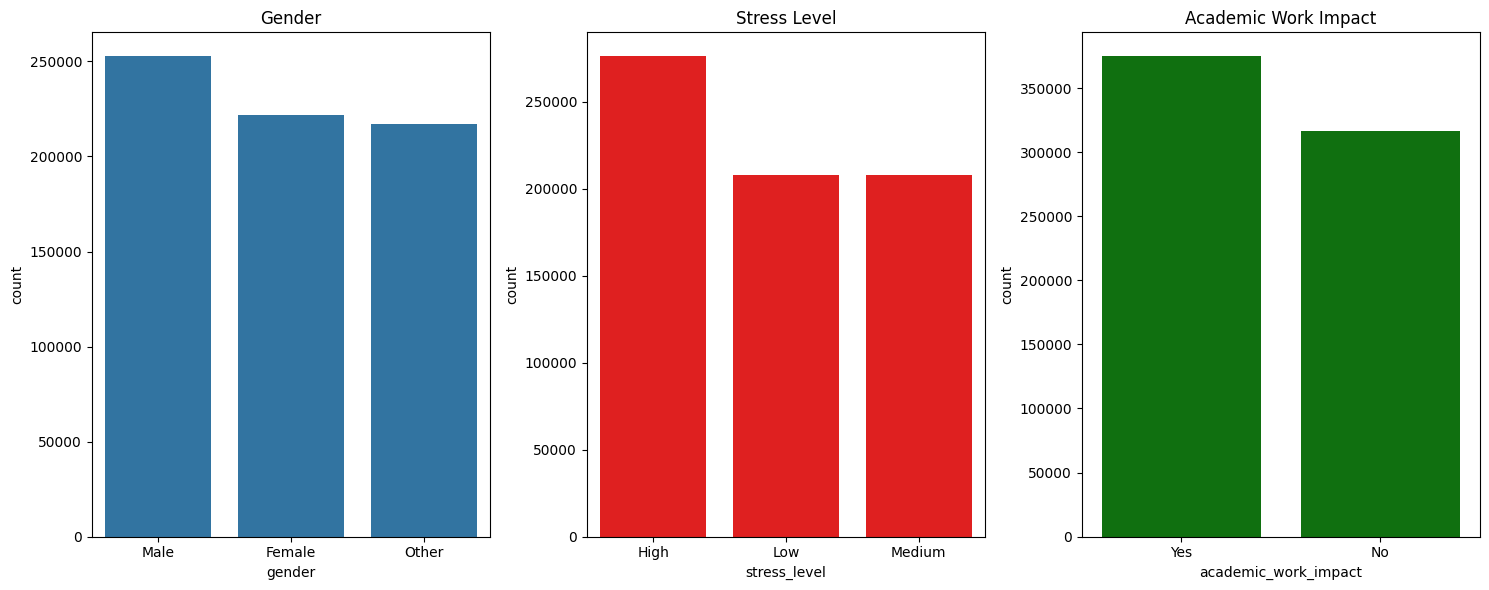

In [19]:
fig, ax = plt.subplots(1,3, figsize = (15,6))

sns.countplot(df_tr_copy, x = 'gender', order = df_tr_copy['gender'].value_counts().index, ax = ax[0])
sns.countplot(df_tr_copy, x = 'stress_level', order = df_tr_copy['stress_level'].value_counts().index, ax = ax[1], color = 'red')
sns.countplot(df_tr_copy, x = 'academic_work_impact', order = df_tr_copy['academic_work_impact'].value_counts().index, ax = ax[2], color = 'green')
ax[0].set_title('Gender')
ax[1].set_title('Stress Level')
ax[2].set_title('Academic Work Impact')
fig.tight_layout()
plt.show()

In [20]:
df_tst_copy = df_tst.copy()
for col in col_mode:
    mode_ = df_tst_copy[col].mode()[0]
    df_tst_copy[col] = df_tst_copy[col].fillna(mode_)

df_tst_copy[col_mode].isnull().sum()

gender                  0
stress_level            0
academic_work_impact    0
dtype: int64

In [21]:
for col in col_mean:
    df_tst_copy = fill_nan(df_tst_copy, col, 'mean')

for col_ in col_median:
    df_tst_copy = fill_nan(df_tst_copy, col_, 'median')

df_tst_copy.isnull().sum()

age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
dtype: int64

In [22]:
# statistical description
df_feat_select = df_tr_copy.copy()
summary = df_feat_select[num_tr.columns].describe().T
summary = summary[['min', '25%', '50%', 'mean', '75%', 'max']]
summary


,min,25%,50%,mean,75%,max
age,18.00,22.00,27.000000,26.631501,31.00,35.00
daily_screen_time_hours,0.50,5.83,7.640865,7.640865,9.56,15.00
social_media_hours,0.00,1.66,2.310000,2.439827,3.10,8.00
gaming_hours,0.00,0.83,1.459265,1.459265,1.90,4.00
work_study_hours,0.00,1.42,2.200000,2.354529,3.11,6.00
sleep_hours,4.50,5.86,6.800000,6.804055,7.78,9.00
notifications_per_day,20.00,102.00,145.894900,145.894900,197.00,250.00
app_opens_per_day,15.00,68.00,102.636781,102.636781,139.00,180.00
weekend_screen_time,0.51,7.72,9.580000,9.496097,11.34,17.56
addicted_label,0.00,0.00,1.000000,0.709424,1.00,1.00


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder

df_tr_copy = df_tr.copy()
df_tst_copy = df_tst.copy()

numeric_cols = ['age', 'social_media_hours', 'work_study_hours','sleep_hours','weekend_screen_time', 'daily_screen_time_hours', 'gaming_hours', 'notifications_per_day', 'app_opens_per_day']
nominal_cols = ['gender']
ordinal_cols = ['stress_level', 'academic_work_impact']

# sort order for ordinal column
stress_lvl = ["Low", "Medium", "High"]
academic = ['No', 'Yes']

# using transformer
num_transformer = Pipeline(steps = [
    ('imputation', SimpleImputer (strategy = 'median'))
])


ordinal_transformer = Pipeline(steps = [
    ('imputation', SimpleImputer (strategy = 'most_frequent')), 
    ('encoder', OrdinalEncoder(categories = [stress_lvl, academic], handle_unknown = 'use_encoded_value', unknown_value = -1))

])

nominal_transformer = Pipeline(steps = [
    ('imputation', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num' , num_transformer, numeric_cols),
        ('cat_norm', nominal_transformer, nominal_cols),
        ('cat_ord', ordinal_transformer, ordinal_cols)
    ],
    remainder = 'drop'
)

X = df_tr_copy.drop(columns = ['addicted_label'])
y = df_tr_copy['addicted_label']


preprocessor

X_tr_ready = preprocessor.fit_transform(X)
X_tr_ready

array([[24.  ,  1.83,  2.11, ...,  0.  ,  1.  ,  0.  ],
       [19.  ,  1.08,  3.03, ...,  0.  ,  1.  ,  0.  ],
       [18.  ,  2.31,  2.2 , ...,  0.  ,  0.  ,  1.  ],
       ...,
       [27.  ,  2.31,  2.06, ...,  1.  ,  1.  ,  0.  ],
       [22.  ,  3.69,  1.35, ...,  1.  ,  2.  ,  1.  ],
       [21.  ,  1.03,  1.01, ...,  1.  ,  1.  ,  1.  ]])

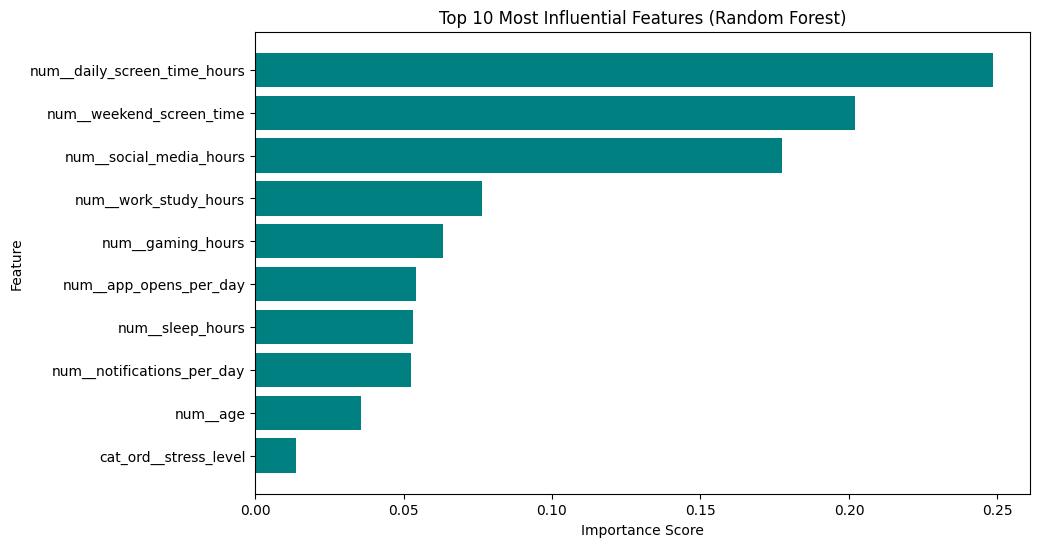

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf.fit(X_tr_ready, y)
new_cols = preprocessor.get_feature_names_out()

feature_imp = rf.feature_importances_

df_feat_imp = pd.DataFrame({
    'feature':new_cols,
    'importance_score':feature_imp
}).sort_values(by = 'importance_score', ascending = False)

plt.figure(figsize = (10,6))
plt.barh(df_feat_imp['feature'].head(10), df_feat_imp['importance_score'].head(10), color = 'teal')
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Most Influential Features (Random Forest)')
plt.show()

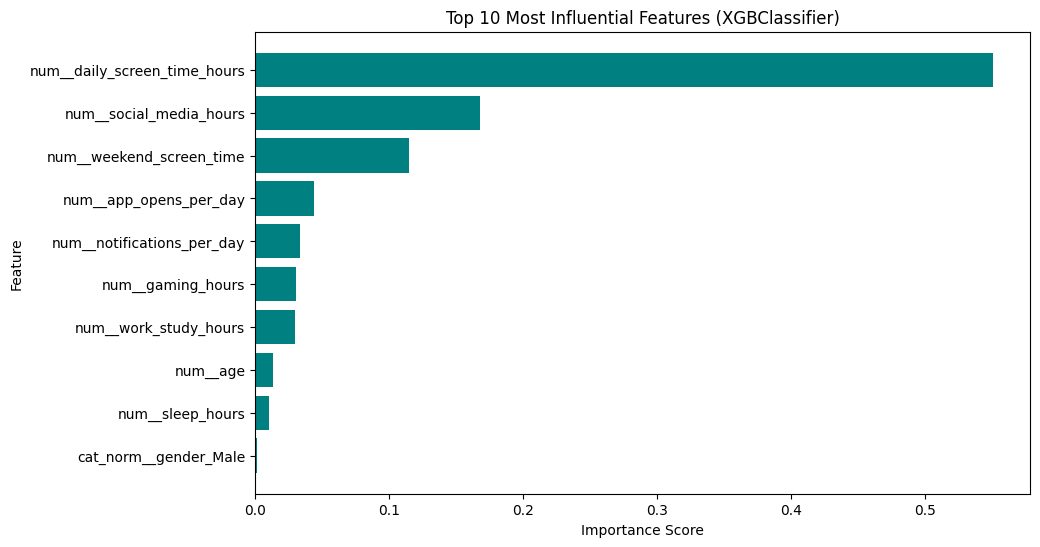

In [25]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(objective = 'binary:logistic', eval_metric = 'auc', n_estimators = 100, learning_rate = 0.05, tree_method = 'hist', random_state = 42)
xgb_model.fit(X_tr_ready, y)

df_feat_imp = pd.DataFrame({
    'feature':new_cols,
    'importance_score_xgb':xgb_model.feature_importances_
}).sort_values(by = 'importance_score_xgb', ascending = False)

plt.figure(figsize = (10,6))
plt.barh(df_feat_imp['feature'].head(10), df_feat_imp['importance_score_xgb'].head(10), color = 'teal')
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Most Influential Features (XGBClassifier)')
plt.show()

In [26]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

search_pipeline = Pipeline(steps = [ ('preprocess', preprocessor), ('model', xgb_model)])
cv_search = StratifiedKFold (n_splits = 5, shuffle = True, random_state = 42)
param_distributions = {
    'model__max_depth': [3, 4, 5],
    'model__min_child_weight': [1,2,3],
    'model__subsample': [0.7, 0.8, 0.95],
    'model__colsample_bytree': [0.7, 0.8, 0.95]
}

search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions = param_distributions,
    n_iter = 20,
    scoring = 'roc_auc',
    cv = cv_search,
    random_state = 42,
    verbose = 2,
    n_jobs = 1,
    refit = True,
    return_train_score = False
)

search.fit(X, y)
print(f"Best CV ROC AUC score: {search.best_score_:.4f}")
print('Best Parameters: ')
for name, value in search.best_params_.items():
    print(f" {name}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__colsample_bytree=0.8, model__max_depth=3, model__min_child_weight=2, model__subsample=0.7; total time=   2.6s
[CV] END model__colsample_bytree=0.8, model__max_depth=3, model__min_child_weight=2, model__subsample=0.7; total time=   2.7s
[CV] END model__colsample_bytree=0.8, model__max_depth=3, model__min_child_weight=2, model__subsample=0.7; total time=   2.7s
[CV] END model__colsample_bytree=0.8, model__max_depth=3, model__min_child_weight=2, model__subsample=0.7; total time=   2.7s
[CV] END model__colsample_bytree=0.8, model__max_depth=3, model__min_child_weight=2, model__subsample=0.7; total time=   2.8s
[CV] END model__colsample_bytree=0.7, model__max_depth=3, model__min_child_weight=1, model__subsample=0.7; total time=   2.7s
[CV] END model__colsample_bytree=0.7, model__max_depth=3, model__min_child_weight=1, model__subsample=0.7; total time=   2.7s
[CV] END model__colsample_bytree=0.7, model__max_depth=3

In [27]:
cv_result = pd.DataFrame(search.cv_results_)
cv_result.columns
results_cols= ['rank_test_score', 'mean_test_score', 'std_test_score', 'param_model__max_depth', 'param_model__min_child_weight', 'param_model__subsample', 'param_model__colsample_bytree']
cv_result[results_cols].sort_values('rank_test_score').head(10)

,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__min_child_weight,param_model__subsample,param_model__colsample_bytree
15,1,0.936188,0.000716,5,1,0.70,0.80
10,2,0.936182,0.000835,5,2,0.80,0.80
2,3,0.936083,0.000753,5,2,0.80,0.70
16,4,0.936015,0.000723,5,1,0.80,0.95
4,5,0.935981,0.000773,5,1,0.70,0.70
14,6,0.932321,0.000808,4,2,0.95,0.95
7,7,0.932280,0.000836,4,3,0.80,0.95
12,8,0.932279,0.000836,4,2,0.80,0.95
6,9,0.932055,0.000848,4,1,0.80,0.70
19,10,0.932040,0.000710,4,2,0.80,0.80


In [28]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
best_param = {
    key.replace('model__', ""):value
    for key, value in search.best_params_.items()
}

X_test = df_tst_copy


cv_final = StratifiedKFold(n_splits = 5, shuffle=True, random_state = 42)
oof_pred = np.zeros(len(X), dtype = float)
test_preds = np.zeros(len(X_test))
fold_scores = []
best_iterations = []

for fold, (train_idx, valid_idx) in enumerate(cv_final.split(X, y), start = 1):
    X_tr = X.iloc[train_idx]
    y_tr = y.iloc[train_idx]
    X_val = X.iloc[valid_idx]
    y_val = y.iloc[valid_idx]

    fold_preprocessor = clone(preprocessor)
    X_tr_transform = fold_preprocessor.fit_transform(X_tr)
    X_val_transform = fold_preprocessor.transform(X_val)
    X_test_transform = fold_preprocessor.transform(X_test)

    xgbmodel = XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        n_estimators=3000,
        learning_rate=0.05,
        tree_method='hist',
        early_stopping_rounds=100,
        random_state=42 + fold,
        **best_param
    )

    xgbmodel.fit(
        X_tr_transform, y_tr, eval_set= [(X_val_transform, y_val)], verbose = False
    )

    valid_pred = xgbmodel.predict_proba(X_val_transform)[:, 1]
    test_pred = xgbmodel.predict_proba(X_test_transform)[:, 1]
    oof_pred[valid_idx] = valid_pred
    test_preds += test_pred/cv_final.n_splits

    fold_auc = roc_auc_score(y_val, valid_pred)
    fold_scores.append(fold_auc)
    best_iterations.append(xgbmodel.best_iteration)

    print(f'Fold {fold}: AUC = {fold_auc:.4f} |' 
          f'Best Iteration: {xgbmodel.best_iteration}')
final_oof_auc = roc_auc_score(y, oof_pred)

print(f'Fold AUC mean       : {np.mean(fold_scores):.5f}')
print(f'Fold AUC std        : {np.std(fold_scores):.5f}')
print(f'Best iteration mean : {np.mean(best_iterations):.1f}')

Fold 1: AUC = 0.9629 |Best Iteration: 2999
Fold 2: AUC = 0.9636 |Best Iteration: 2951
Fold 3: AUC = 0.9638 |Best Iteration: 2966
Fold 4: AUC = 0.9645 |Best Iteration: 2999
Fold 5: AUC = 0.9633 |Best Iteration: 2999
Fold AUC mean       : 0.96363
Fold AUC std        : 0.00054
Best iteration mean : 2982.8


In [29]:
submission = pd.DataFrame({'id': df_tst_copy.index, 'addicted_label':test_preds})
submission.to_csv('submission.csv', index = False)
print('submission.csv is saved')
submission.head()

submission.csv is saved


,id,addicted_label
0,691369,0.999630
1,691370,0.944777
2,691371,0.942235
3,691372,0.990277
4,691373,0.999047
